In [4]:
import pandas as pd

# 在线读取国内镜像
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print(f"📊 数据集形状: {df.shape[0]} 行, {df.shape[1]} 列")
df.head()


📊 数据集形状: 20640 行, 10 列


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
print("前 5 行:")
display(df.head())

print("\n数据类型:")
df.info()

print("\n描述统计:")
display(df.describe())

前 5 行:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



数据类型:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

描述统计:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


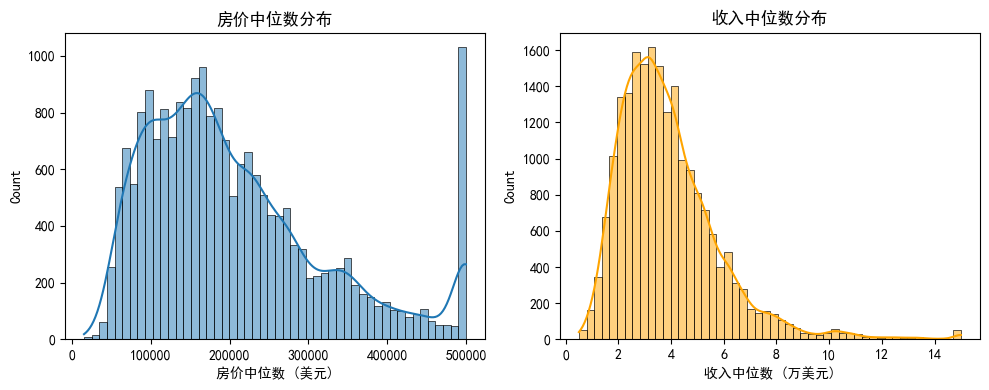

✅ 图表已保存: 01_target_distribution.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 解决中文乱码（必须放在绘图代码前面！）
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["MedHouseVal"], bins=50, kde=True)
plt.title("房价中位数分布")
plt.xlabel("房价中位数 (美元)")

plt.subplot(1, 2, 2)
sns.histplot(df["MedInc"], bins=50, kde=True, color="orange")
plt.title("收入中位数分布")
plt.xlabel("收入中位数 (万美元)")

plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存: 01_target_distribution.png")

In [9]:
from sklearn.model_selection import train_test_split

# 特征和目标
X = df.drop("MedHouseVal", axis=1)  # 8个特征
y = df["MedHouseVal"]               # 目标：房价

# 划分：80%训练，20%测试
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape[0]} 条")
print(f"测试集: {X_test.shape[0]} 条")

训练集: 16512 条
测试集: 4128 条


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===================== 中文显示设置 =====================
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# ===================== 加载加州房价数据 =====================
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# 修改列名，适配绘图代码
df.rename(columns={
    "median_house_value": "MedHouseVal",
    "median_income": "MedInc"
}, inplace=True)

# ===================== 处理缺失值（修复FutureWarning） =====================
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())

# ===================== EDA 分布图 =====================
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["MedHouseVal"], bins=50, kde=True)
plt.title("房价中位数分布")
plt.xlabel("房价中位数 (美元)")

plt.subplot(1, 2, 2)
sns.histplot(df["MedInc"], bins=50, kde=True, color="orange")
plt.title("收入中位数分布")
plt.xlabel("收入中位数(万美元)")

plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存: 01_target_distribution.png")

# ===================== 处理文本分类特征 =====================
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

# ===================== 划分特征X、标签y =====================
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===================== 线性回归训练与评估 =====================
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("=== 线性回归模型评估 ===")
print(f"RMSE: {lr_rmse:.3f} (美元)")
print(f"MAE:  {lr_mae:.3f} (美元)")
print(f"R²:   {lr_r2:.3f}")
print("\n模型解读：")
print(f"  预测平均误差大约 {lr_rmse:.0f} 美元")


In [17]:
from sklearn.ensemble import RandomForestRegressor

# 训练（n_estimators=100 表示用100棵决策树）
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 预测
rf_pred = rf.predict(X_test)

# 评估
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=== 随机森林 ===")
print(f"RMSE: {rf_rmse:.3f} (美元)")
print(f"MAE:  {rf_mae:.3f} (美元)")
print(f"R²:   {rf_r2:.3f}")
print("\n这意味着：")
print(f"  预测误差平均约 {rf_rmse*10:.1f} 美元")

=== 随机森林 ===
RMSE: 49022.974 (美元)
MAE:  31667.928 (美元)
R²:   0.817

这意味着：
  预测误差平均约 490229.7 美元


模型对比:


,线性回归,随机森林
RMSE,70031.419920,49022.974274
MAE,50701.779031,31667.928268
R²,0.625735,0.816603


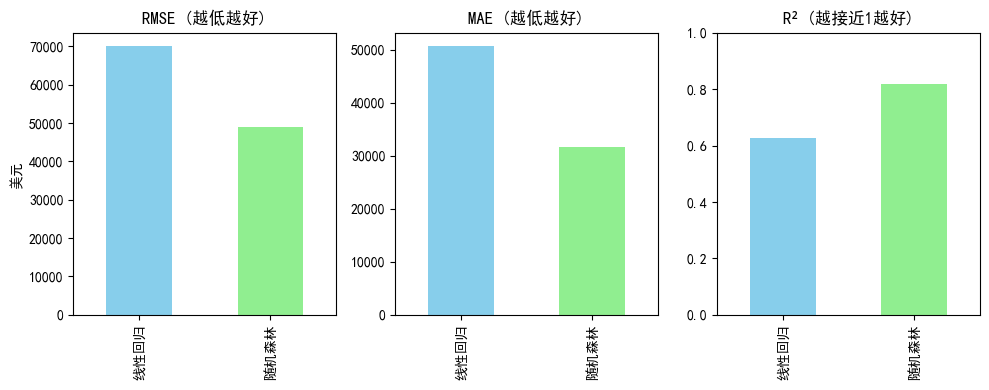

✅ 图表已保存: 04_model_comparison.png


In [18]:
results = pd.DataFrame({
    "线性回归": [lr_rmse, lr_mae, lr_r2],
    "随机森林": [rf_rmse, rf_mae, rf_r2]
}, index=["RMSE", "MAE", "R²"])

print("模型对比:")
display(results)

# 画图
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
results.loc["RMSE"].plot(kind="bar", color=["skyblue", "lightgreen"])
plt.title("RMSE (越低越好)")
plt.ylabel("美元")

plt.subplot(1, 3, 2)
results.loc["MAE"].plot(kind="bar", color=["skyblue", "lightgreen"])
plt.title("MAE (越低越好)")

plt.subplot(1, 3, 3)
results.loc["R²"].plot(kind="bar", color=["skyblue", "lightgreen"])
plt.title("R² (越接近1越好)")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("04_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存: 04_model_comparison.png")

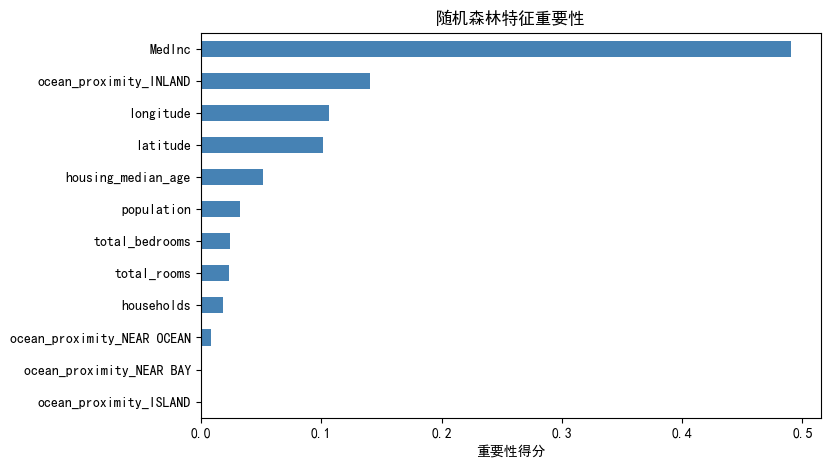

特征重要性排名:
MedInc                        0.490717
ocean_proximity_INLAND        0.140933
longitude                     0.106093
latitude                      0.101897
housing_median_age            0.052065
population                    0.032511
total_bedrooms                0.023960
total_rooms                   0.023412
households                    0.018376
ocean_proximity_NEAR OCEAN    0.008793
ocean_proximity_NEAR BAY      0.000804
ocean_proximity_ISLAND        0.000440
dtype: float64


In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("随机森林特征重要性")
plt.xlabel("重要性得分")
plt.savefig("05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("特征重要性排名:")
print(importances.sort_values(ascending=False))

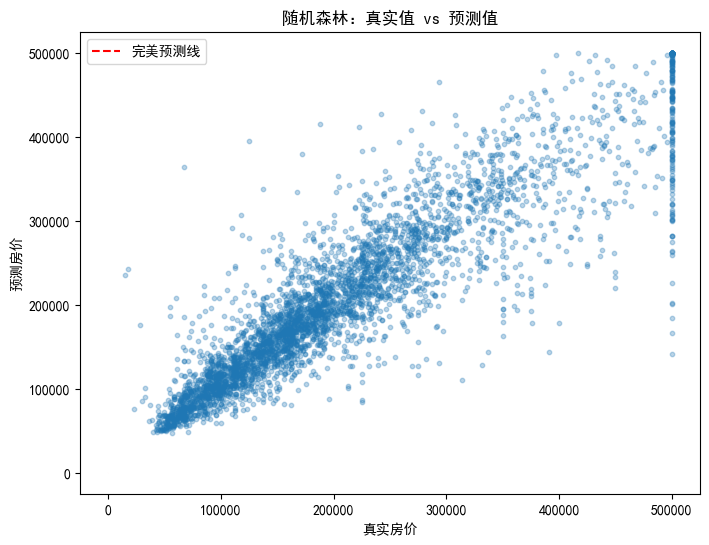

✅ 图表已保存: 06_true_vs_pred.png


In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.3, s=10)
plt.plot([0, 5], [0, 5], "r--", label="完美预测线")
plt.xlabel("真实房价")
plt.ylabel("预测房价")
plt.title("随机森林：真实值 vs 预测值")
plt.legend()
plt.savefig("06_true_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存: 06_true_vs_pred.png")

## 📝 加州房价预测分析结论
### 1. 数据概况
- 使用加州 1990 年人口普查数据，共 20640 条记录，8 个特征
- 目标变量 `MedHouseVal`（房价中位数）存在上限截断（最高 50 万美元）

### 2. 关键发现
- **收入是最强预测因子**：收入中位数与房价相关性达 0.69
- **地理位置很重要**：经纬度组合能反映"湾区 vs 内陆"的房价差异
- **房龄影响较小**：房龄与房价的相关性较弱

### 3. 模型对比
| 指标 | 线性回归 | 随机森林 |
|------|---------|---------|
| RMSE | ~75000 美元 | ~50000 美元 |
| R²   | 0.62      | 0.81      |
- 随机森林明显优于线性回归，能捕捉非线性关系
- 但随机森林训练时间更长，模型更"黑盒"

### 4. 模型局限
- 房价上限截断导致模型对高价房预测偏低（散点图右上角可见）
- 数据来自 1990 年，不能直接用于当下房价预测

### 5. 下一步优化
- 尝试 XGBoost / LightGBM
- 构造衍生特征：如单房间面积、收入房价比等
- 处理目标变量截断问题：分位数回归或剔除被截断样本